# TSP fund analysis and long-term portfolio optimization

This notebook downloads the official TSP fund price history, plots every fund, calculates **Max Drawdown, Sharpe, CAGR, Sortino, and Calmar**, and then builds a long-only portfolio using a constrained maximum-Sharpe optimization.

> The results are historical estimates, not investment advice. The optimizer is sensitive to the sample period, expected-return estimates, and the maximum-weight constraint.

In [294]:
from pathlib import Path
import io
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
import yfinance as yf
from scipy.optimize import minimize

In [301]:
warnings.filterwarnings('ignore', category=RuntimeWarning)
plt.style.use('seaborn-v0_8-whitegrid')

In [302]:
DATA_URL = 'https://www.tsp.gov/data/fund-price-history.csv'
DATA_DIR = Path('data')
CACHE_PATH = DATA_DIR / 'fund-price-history.csv'
RISK_FREE_RATE = 0.02       # annual risk-free rate used for Sharpe/Sortino
TRADING_DAYS = 252
MIN_WEIGHT = 0.03           # global minimum per eligible fund; use 0.00 for only MIN_ALLOCATIONS floors
MAX_WEIGHT = 1.0           # maximum allocation per eligible fund; raise toward 1.00 for more concentration
MIN_HISTORY_YEARS = 20
MIN_ALLOCATIONS = {
    #'C Fund': 0.70
    # 'G Fund': 0.10,       # example: require at least 10% in the G Fund
}
TARGET_CAGR = 0.08         # set to None to maximize Sharpe without a CAGR target
MAX_FUNDS = 3            # e.g. 4; None allows all eligible funds
FUND_RANKING_METRIC = 'Sharpe'  # metric used to select funds when MAX_FUNDS is set
START_DATE = None           # e.g. '2010-01-01'; None uses all available history
BENCHMARK_TICKER = 'SPY'
BENCHMARK_CACHE_PATH = DATA_DIR / f'{BENCHMARK_TICKER.lower()}-adjusted-close.csv'

## Download and clean the data

The file is cached locally so subsequent runs do not need to download it again. The parser identifies the date column and treats the remaining numeric columns as funds, which makes it resilient to TSP adding or renaming lifecycle funds.

In [303]:
DATA_DIR.mkdir(exist_ok=True)

if not CACHE_PATH.exists():
    headers = {
        'User-Agent': (
            'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) '
            'AppleWebKit/537.36 (KHTML, like Gecko) '
            'Chrome/131.0.0.0 Safari/537.36'
        ),
        'Accept': 'text/csv,text/plain;q=0.9,*/*;q=0.8',
        'Referer': 'https://www.tsp.gov/',
    }
    response = requests.get(DATA_URL, headers=headers, timeout=30)
    response.raise_for_status()
    CACHE_PATH.write_bytes(response.content)
    print(f'Downloaded {len(response.content):,} bytes to {CACHE_PATH}')
else:
    print(f'Using cached file: {CACHE_PATH}')

raw = pd.read_csv(CACHE_PATH)
date_candidates = [c for c in raw.columns if str(c).strip().lower() in {'date', 'as of date', 'price date'}]
date_col = date_candidates[0] if date_candidates else raw.columns[0]
raw[date_col] = pd.to_datetime(raw[date_col], errors='coerce')
prices = raw.set_index(date_col).sort_index()
prices = prices.apply(lambda s: pd.to_numeric(s.astype(str).str.replace(',', '', regex=False), errors='coerce'))
prices = prices.loc[:, prices.notna().sum() >= 20].dropna(how='all')
if START_DATE is not None:
    prices = prices.loc[pd.Timestamp(START_DATE):]
prices = prices[~prices.index.duplicated(keep='last')].dropna(axis=1, how='all')
print(f'{prices.index.min().date()} to {prices.index.max().date()} | {prices.shape[1]} funds | {len(prices):,} observations')
display(prices.tail())

Using cached file: data/fund-price-history.csv
2003-05-31 to 2026-08-21 | 16 funds | 5,800 observations


,L Income,L 2030,L 2035,L 2040,L 2045,L 2050,L 2055,L 2060,L 2065,L 2070,L 2075,G Fund,F Fund,C Fund,S Fund,I Fund
Date,,,,,,,,,,,,,,,,
2026-08-17,31.1409,64.0591,19.7642,76.3233,21.2487,47.3693,25.0033,25.0000,24.9966,14.8148,12.9408,20.1367,20.8237,124.7825,120.6396,66.4152
2026-08-18,31.0541,63.7041,19.6298,75.7571,21.0799,46.9677,24.7443,24.7411,24.7377,14.6614,12.8067,20.1394,20.8421,123.9253,118.6624,65.5124
2026-08-19,31.0765,63.7709,19.6536,75.8562,21.1090,47.0350,24.7777,24.7745,24.7712,14.6813,12.8241,20.1421,20.9407,124.1969,118.9512,65.4902
2026-08-20,31.0289,63.5847,19.5835,75.5610,21.0211,46.8269,24.6505,24.6473,24.6440,14.6058,12.7582,20.1448,20.8751,123.1350,117.5638,65.6397
2026-08-21,31.0897,63.8225,19.6727,75.9347,21.1322,47.0907,24.8216,24.8183,24.8150,14.7071,12.8467,20.1475,20.8404,123.6762,118.5706,66.3161


## Plot every fund

Each series is rebased to 100 at its first available observation. This compares growth rather than nominal share prices.

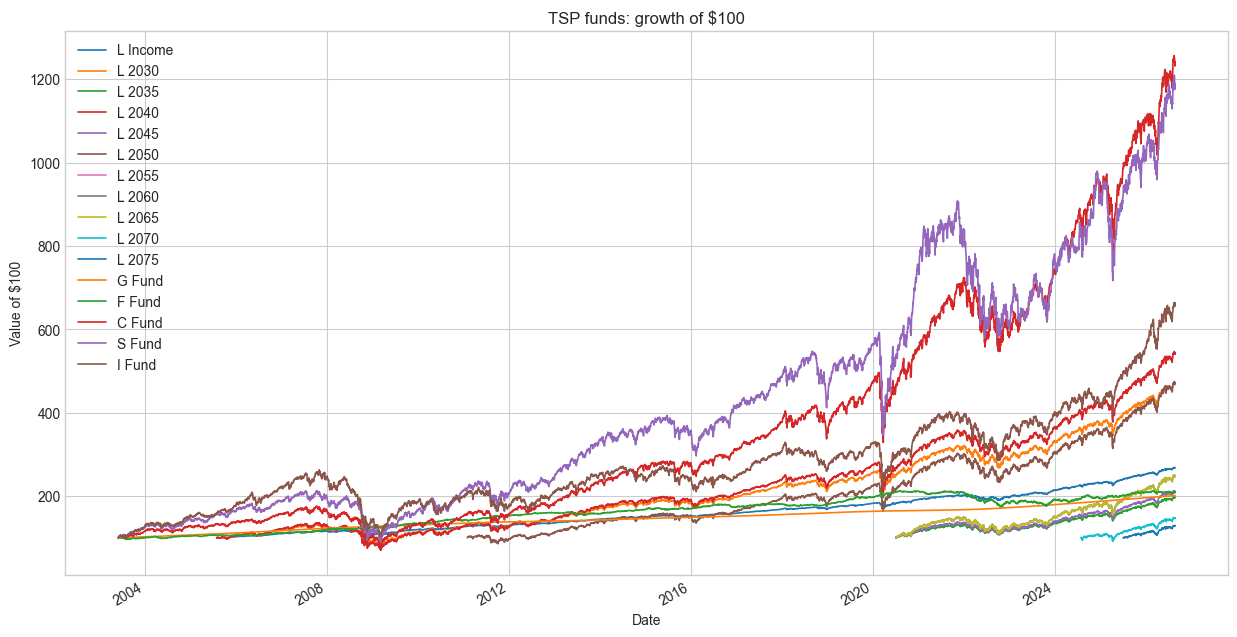

In [304]:
normalized = prices.div(prices.bfill().iloc[0]).mul(100)
ax = normalized.plot(figsize=(15, 8), linewidth=1.2, title='TSP funds: growth of $100')
ax.set_ylabel('Value of $100')
ax.set_xlabel('Date')
plt.show()

## Performance metrics

Metrics use daily observations and 252 trading days per year. MaxDD is the worst peak-to-trough loss; Sortino uses only negative excess daily returns; Calmar is CAGR divided by the absolute maximum drawdown.

In [305]:
def performance_metrics(series, risk_free=RISK_FREE_RATE):
    series = series.dropna()
    daily_returns = series.pct_change().dropna()
    years = (series.index[-1] - series.index[0]).days / 365.25
    cagr = (series.iloc[-1] / series.iloc[0]) ** (1 / years) - 1 if years > 0 else np.nan
    drawdown = series / series.cummax() - 1
    max_dd = drawdown.min()
    daily_rf = (1 + risk_free) ** (1 / TRADING_DAYS) - 1
    excess = daily_returns - daily_rf
    sharpe = np.sqrt(TRADING_DAYS) * excess.mean() / daily_returns.std(ddof=1)
    downside = np.minimum(excess, 0)
    downside_dev = np.sqrt(np.mean(downside ** 2))
    sortino = np.sqrt(TRADING_DAYS) * excess.mean() / downside_dev if downside_dev else np.nan
    calmar = cagr / abs(max_dd) if max_dd < 0 else np.nan
    return pd.Series({ 'Years': years, 'CAGR': cagr, 'Sharpe': sharpe, 'MaxDD': max_dd, 'Sortino': sortino, 'Calmar': calmar})

fund_metrics = prices.apply(performance_metrics).T.sort_values(['Years', 'CAGR'], ascending=False)
display(fund_metrics.style.format({'CAGR': '{:.2%}',  'Sharpe': '{:.2f}','MaxDD': '{:.2%}',  'Sortino': '{:.2f}', 'Calmar': '{:.2f}', 'Years': '{:.1f}'}))

,Years,CAGR,Sharpe,MaxDD,Sortino,Calmar
C Fund,23.2,11.44%,0.57,-55.22%,0.80,0.21
S Fund,23.2,11.24%,0.51,-57.43%,0.70,0.20
I Fund,23.2,8.49%,0.42,-60.89%,0.59,0.14
F Fund,23.2,3.21%,0.30,-17.98%,0.43,0.18
G Fund,23.2,3.06%,3.64,0.00%,17.66,nan
L 2040,21.1,8.36%,0.49,-48.43%,0.68,0.17
L 2030,21.1,7.61%,0.50,-43.30%,0.69,0.18
L Income,21.1,4.79%,0.71,-11.01%,0.99,0.44
L 2050,15.6,10.48%,0.65,-29.20%,0.90,0.36
L 2055,6.1,15.96%,0.91,-26.42%,1.32,0.60


## Long-term portfolio optimization

The method below maximizes historical annualized Sharpe subject to: (1) configurable long-only bounds from `MIN_WEIGHT` to `MAX_WEIGHT`, (2) any fund-specific minimums in `MIN_ALLOCATIONS`, (3) weights summing to 100%, and (4) an optional minimum historical CAGR in `TARGET_CAGR`. If `MAX_FUNDS` is set, required funds are retained and remaining slots are filled by the highest-ranked funds using `FUND_RANKING_METRIC`. Lifecycle funds with less than `MIN_HISTORY_YEARS` are excluded from the optimization to avoid letting a short favorable window dominate. The CAGR target is estimated from daily rebalanced returns and is historical, not a forecast.

In [306]:
def annualized_portfolio_stats(weights, returns, risk_free=RISK_FREE_RATE):
    mean = returns.mean() * TRADING_DAYS
    cov = returns.cov() * TRADING_DAYS
    ret = float(weights @ mean)
    vol = float(np.sqrt(weights @ cov @ weights))
    sharpe = (ret - risk_free) / vol if vol > 0 else np.nan
    return ret, vol, sharpe

def annualized_portfolio_cagr(weights, returns):
    daily_returns = returns @ weights
    return float((1 + daily_returns).prod() ** (TRADING_DAYS / len(daily_returns)) - 1)

eligible = prices.loc[:, prices.notna().sum() >= MIN_HISTORY_YEARS * TRADING_DAYS].dropna()
candidate_funds = list(eligible.columns)
unknown_minimums = set(MIN_ALLOCATIONS) - set(candidate_funds)
if unknown_minimums:
    raise ValueError(f'MIN_ALLOCATIONS contains funds not eligible for optimization: {sorted(unknown_minimums)}')

if FUND_RANKING_METRIC not in fund_metrics.columns:
    raise ValueError(f'Unknown FUND_RANKING_METRIC: {FUND_RANKING_METRIC}')
if MAX_FUNDS is not None:
    if not isinstance(MAX_FUNDS, int) or MAX_FUNDS < 1:
        raise ValueError('MAX_FUNDS must be a positive integer or None.')
    if MAX_FUNDS < len(MIN_ALLOCATIONS):
        raise ValueError('MAX_FUNDS must be at least the number of required minimum-allocation funds.')
    ranked_funds = (
        fund_metrics.loc[candidate_funds, FUND_RANKING_METRIC]
        .sort_values(ascending=False)
        .index
        .tolist()
    )
    required_funds = list(MIN_ALLOCATIONS)
    selected_funds = required_funds + [
        fund for fund in ranked_funds if fund not in required_funds
    ][:MAX_FUNDS - len(required_funds)]
else:
    selected_funds = candidate_funds

eligible = eligible.loc[:, selected_funds]
returns = eligible.pct_change().dropna()
funds = list(returns.columns)
print(f'Using {len(funds)} funds: {", ".join(funds)}')

lower_bounds = np.array([
    max(MIN_WEIGHT, float(MIN_ALLOCATIONS.get(fund, 0.0)))
    for fund in funds
])
upper_bounds = np.full(len(funds), MAX_WEIGHT, dtype=float)
if lower_bounds.sum() > 1 or lower_bounds.max(initial=0) > MAX_WEIGHT:
    raise ValueError('Minimum allocations are too high to construct a fully invested portfolio.')
if upper_bounds.sum() < 1 or MIN_WEIGHT > MAX_WEIGHT:
    raise ValueError('MIN_WEIGHT and MAX_WEIGHT cannot form a feasible portfolio.')
bounds = list(zip(lower_bounds, upper_bounds))

def objective(weights):
    return -annualized_portfolio_stats(weights, returns)[2]

initial = lower_bounds.copy()
remaining = 1 - initial.sum()
capacity = upper_bounds - lower_bounds
if remaining > 1e-12:
    if capacity.sum() < remaining:
        raise ValueError('The configured allocation bounds cannot sum to 100%.')
    initial += remaining * capacity / capacity.sum()
constraints = [{'type': 'eq', 'fun': lambda w: w.sum() - 1}]
if TARGET_CAGR is not None:
    constraints.append({
        'type': 'ineq',
        'fun': lambda w: annualized_portfolio_cagr(w, returns) - TARGET_CAGR,
    })

result = minimize(objective, initial, method='SLSQP', bounds=bounds,
                  constraints=constraints,
                  options={'maxiter': 2000, 'ftol': 1e-10, 'disp': False})
if not result.success:
    raise RuntimeError(f'Optimization failed: {result.message}')

optimized_cagr = annualized_portfolio_cagr(result.x, returns)
if TARGET_CAGR is not None and optimized_cagr < TARGET_CAGR - 1e-4:
    raise RuntimeError(
        f'Optimization could not reach the {TARGET_CAGR:.2%} CAGR target; '
        f'best feasible result was {optimized_cagr:.2%}.'
    )
weights = pd.Series(result.x, index=funds, name='Weight')
weights = weights[weights > 1e-4].sort_values(ascending=False)
print(f'Optimized {len(funds)} funds; {len(weights)} have non-zero allocations.')
print(f'Estimated historical CAGR: {optimized_cagr:.2%}')
display(weights.to_frame().style.format('{:.2%}'))

Using 3 funds: G Fund, L Income, C Fund
Optimized 3 funds; 3 have non-zero allocations.
Estimated historical CAGR: 8.00%


,Weight
C Fund,54.91%
G Fund,42.09%
L Income,3.00%


## Optimized allocation and portfolio metrics

The portfolio is evaluated on the same daily price history, with missing values removed before optimization. The resulting table reports the requested allocation and risk/return measures.

Optimized allocation


,Allocation,MaxDD,Sharpe,CAGR,Sortino,Calmar
C Fund,54.91%,-55.22%,0.57,11.44%,0.80,0.21
G Fund,42.09%,0.00%,3.64,3.06%,17.66,nan
L Income,3.00%,-11.01%,0.71,4.79%,0.99,0.44


Portfolio metrics


,Portfolio
Years,21.054073
CAGR,0.079195
Sharpe,0.588447
MaxDD,-0.328016
Sortino,0.823276
Calmar,0.241436


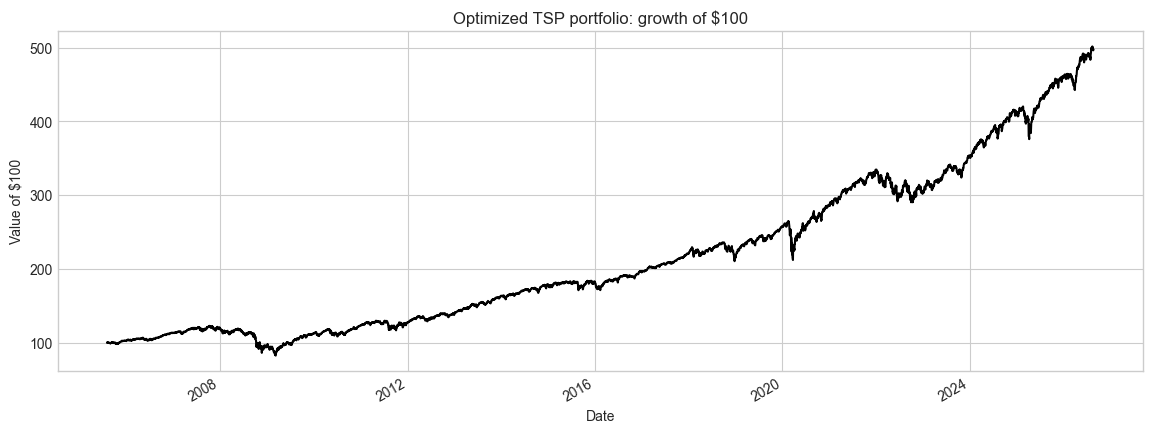

In [307]:
portfolio_returns = returns @ weights.reindex(returns.columns).fillna(0)
portfolio_prices = (1 + portfolio_returns).cumprod()
portfolio_metrics = performance_metrics(portfolio_prices)
allocation_report = pd.DataFrame({'Allocation': weights})
allocation_report = allocation_report.join(fund_metrics[['MaxDD', 'Sharpe', 'CAGR', 'Sortino', 'Calmar']])
print('Optimized allocation')
display(allocation_report.style.format({'Allocation': '{:.2%}', 'MaxDD': '{:.2%}', 'Sharpe': '{:.2f}', 'CAGR': '{:.2%}', 'Sortino': '{:.2f}', 'Calmar': '{:.2f}'}))
print('Portfolio metrics')
display(portfolio_metrics.to_frame('Portfolio').style.format({'MaxDD': '{:.2%}', 'Sharpe': '{:.2f}', 'CAGR': '{:.2%}', 'Sortino': '{:.2f}', 'Calmar': '{:.2f}', 'Years': '{:.1f}'}))

portfolio_index = portfolio_prices / portfolio_prices.iloc[0] * 100
ax = portfolio_index.plot(figsize=(14, 5), title='Optimized TSP portfolio: growth of $100', color='black')
ax.set_ylabel('Value of $100')
plt.show()

## Benchmark against SPY

SPY uses adjusted closing prices, including distributions. The comparison uses the overlapping date range and the same metrics as the optimized TSP portfolio.

Using cached SPY data: data/spy-adjusted-close.csv
Comparison period: 2011-01-31 to 2026-08-21


,Years,CAGR,Sharpe,MaxDD,Sortino,Calmar
Optimized TSP,15.6,9.30%,0.78,-19.83%,1.10,0.47
SPY,15.6,14.14%,0.75,-33.72%,1.05,0.42


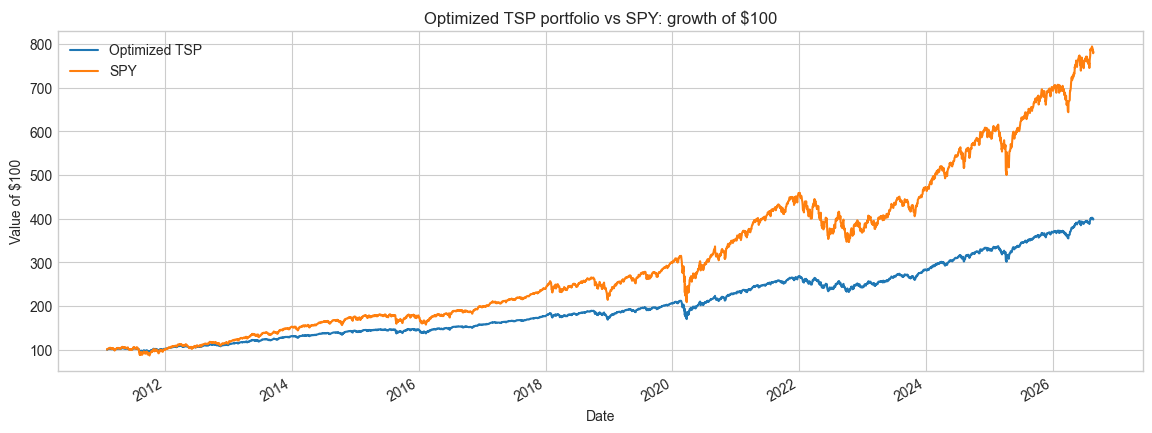

In [308]:
if BENCHMARK_CACHE_PATH.exists():
    benchmark_frame = pd.read_csv(BENCHMARK_CACHE_PATH, index_col=0, parse_dates=True)
    benchmark_prices = benchmark_frame.iloc[:, 0].rename(BENCHMARK_TICKER)
    print(f'Using cached {BENCHMARK_TICKER} data: {BENCHMARK_CACHE_PATH}')
else:
    benchmark_start = portfolio_prices.index.min().strftime('%Y-%m-%d')
    benchmark_end = (portfolio_prices.index.max() + pd.Timedelta(days=1)).strftime('%Y-%m-%d')
    benchmark_download = yf.download(
        BENCHMARK_TICKER,
        start=benchmark_start,
        end=benchmark_end,
        auto_adjust=True,
        progress=False,
        threads=False,
    )
    if benchmark_download.empty:
        raise RuntimeError(f'No benchmark data returned for {BENCHMARK_TICKER}.')
    benchmark_prices = benchmark_download['Close']
    if isinstance(benchmark_prices, pd.DataFrame):
        benchmark_prices = (
            benchmark_prices[BENCHMARK_TICKER]
            if BENCHMARK_TICKER in benchmark_prices.columns
            else benchmark_prices.iloc[:, 0]
        )
    benchmark_prices = benchmark_prices.rename(BENCHMARK_TICKER).dropna()
    benchmark_prices.to_frame().to_csv(BENCHMARK_CACHE_PATH)
    print(f'Downloaded {BENCHMARK_TICKER} data to {BENCHMARK_CACHE_PATH}')

benchmark_prices.index = pd.to_datetime(benchmark_prices.index)
if benchmark_prices.index.tz is not None:
    benchmark_prices.index = benchmark_prices.index.tz_localize(None)
comparison = pd.concat(
    [portfolio_prices.rename('Optimized TSP'), benchmark_prices],
    axis=1,
).dropna()
if comparison.empty:
    raise ValueError('The TSP portfolio and benchmark have no overlapping dates.')

comparison_metrics = comparison.apply(performance_metrics).T
print(f'Comparison period: {comparison.index.min().date()} to {comparison.index.max().date()}')
display(comparison_metrics.style.format({
    'MaxDD': '{:.2%}', 'Sharpe': '{:.2f}', 'CAGR': '{:.2%}',
    'Sortino': '{:.2f}', 'Calmar': '{:.2f}', 'Years': '{:.1f}',
}))

comparison_index = comparison.div(comparison.iloc[0]).mul(100)
ax = comparison_index.plot(figsize=(14, 5), title='Optimized TSP portfolio vs SPY: growth of $100')
ax.set_ylabel('Value of $100')
ax.set_xlabel('Date')
plt.show()